## imports

In [85]:
import mne
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
from sys import getsizeof
import torch

In [86]:
dir_base = "../../"
print(os.path.abspath(dir_base))

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


In [88]:
sys.path.append(os.path.abspath(os.path.join(dir_base, "backend", "experiments_xeegnet")))
sys.path.append(os.path.abspath(os.path.join(dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main")))
sys.path.append(os.path.abspath(os.path.join(dir_base, "backend", "models")))

In [89]:
%load_ext autoreload
%autoreload 2
from data_loading_expirements.load_data_pythonfun import *
from data_utils.load_data import *
from data_utils.perpare_data import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
sys.path.append("../")


from AllFnc.models import ShallowNet, ShallowNet2
# from AllFnc.models import *
# from AllFnc.models import *

# IMPORT SELFEEG
import selfeeg
import selfeeg.models as zoo
import selfeeg.dataloading as dl

In [91]:
# IMPORT LIBRARIES
import argparse
import glob
from itertools import chain, combinations, product
import math
import importlib
import os
import random
import pickle
import copy

# IMPORT STANDARD PACKAGES
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
from scipy.signal import welch, firwin
from scipy import stats

# import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import balanced_accuracy_score

# IMPORT TORCH
import torch
import torch.nn as nn
from torchaudio import transforms
from torch.utils.data import DataLoader

# IMPORT SELFEEG
import selfeeg
import selfeeg.models as zoo
import selfeeg.dataloading as dl
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


# IMPORT REPOSITORY FUNCTIONS
import AllFnc
from AllFnc import split
from AllFnc.models import ShallowNet2

# from AllFnc.models import *
from AllFnc.training import loadEEG, lossBinary, lossMulti, train_model, get_performances, GetLearningRate

# IMPORT EEGVISLIB
# from AllFnc import eegvislib


import warnings

warnings.filterwarnings("ignore", message="Using padding='same'", category=UserWarning)

### Path settings

In [92]:
participant_id_int = 1
# get_participant_id

participant_id = get_participant_id(participant_id_int)
print(participant_id)

participant_id = "001"
participant_id_long = f"sub-{participant_id}"

001


## Read Data

In [93]:
sep = os.sep

In [ ]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
dir_data_abs = os.path.abspath(dir_data)
data_path = os.path.join(dir_data, "sub-001", "eeg", "sub-001_task-eyesclosed_eeg.set")

dir_shallownetXAI = os.path.join(dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main")

# data_path = os.path.join(dir_data_abs, 'ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set')

### Metadata / y

In [205]:
disease_mapping = {"A": "Alzheimer Disease Group", "F": "Frontotemporal Dementia Group", "C": "Healthy Group"}

disease_encoding = {
    "A": 1,
    "F": 2,
    "C": 0,
}


df_metadata = load_metadata(dir_data=dir_data)

# metadata_path = os.path.join(dir_data, 'participants.tsv')
# df_metadata = pd.read_csv(metadata_path, sep='\t')
# df_metadata['group_long'] = df_metadata['Group'].map(disease_mapping)
# df_metadata['group_encoded'] = df_metadata['Group'].map(disease_encoding)
df_metadata

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded,participant_id_int
0,sub-001,F,57,A,16,Alzheimer Disease Group,1,1
1,sub-002,F,78,A,22,Alzheimer Disease Group,1,2
2,sub-003,M,70,A,14,Alzheimer Disease Group,1,3
3,sub-004,F,67,A,20,Alzheimer Disease Group,1,4
4,sub-005,M,70,A,22,Alzheimer Disease Group,1,5
...,...,...,...,...,...,...,...,...
83,sub-084,F,71,F,24,Frontotemporal Dementia Group,2,84
84,sub-085,M,64,F,26,Frontotemporal Dementia Group,2,85
85,sub-086,M,49,F,26,Frontotemporal Dementia Group,2,86
86,sub-087,M,73,F,24,Frontotemporal Dementia Group,2,87


In [ ]:
df_metadata

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded
0,sub-001,F,57,A,16,Alzheimer Disease Group,1
1,sub-002,F,78,A,22,Alzheimer Disease Group,1
2,sub-003,M,70,A,14,Alzheimer Disease Group,1
3,sub-004,F,67,A,20,Alzheimer Disease Group,1
4,sub-005,M,70,A,22,Alzheimer Disease Group,1
...,...,...,...,...,...,...,...
83,sub-084,F,71,F,24,Frontotemporal Dementia Group,2
84,sub-085,M,64,F,26,Frontotemporal Dementia Group,2
85,sub-086,M,49,F,26,Frontotemporal Dementia Group,2
86,sub-087,M,73,F,24,Frontotemporal Dementia Group,2


In [96]:
participant_ids = [1, 2, 3, 4, 5, 6, 40, 41, 42, 43, 44, 45, 80, 81, 82, 83, 84, 85]

# participant_ids = [
#     1,2,3,
#     40,41,42,
#     80,81,82,
# ]

df_eeg = load_multiple_eegfiles(
    dir_data=dir_data,
    participant_ids=participant_ids,  # , 43
    gen_path_func=gen_filename,
    df_metadata=df_metadata,
    # n_max = 10000
)

Total memory usage of combined df_eeg: 586.22 MB


In [ ]:
print(df_eeg.shape)
df_eeg.head()

,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,...,F8,T3,T4,T5,T6,Fz,Cz,Pz,participant_id,diagnosis
0,0.000000,-189.892563,-141.845688,-107.373039,28.466799,-108.447258,-36.474609,-73.583984,173.486328,149.462891,...,-112.158195,-59.130859,-12.158201,-78.271477,-131.396469,-103.271477,-18.212889,-126.708977,sub-001,1
1,0.002000,-180.419907,-137.353500,-100.048820,32.275391,-103.369133,-33.642578,-69.384766,177.099609,150.146484,...,-108.544914,-54.736328,-9.423826,-75.537102,-128.173813,-98.681633,-14.404295,-122.900383,sub-001,1
2,0.004000,-166.992172,-135.058578,-105.761711,35.351562,-101.953117,-29.882812,-67.968742,180.078125,144.238281,...,-103.710930,-53.320312,-5.273437,-85.546867,-124.609367,-98.535149,-11.523437,-120.410149,sub-001,1
3,0.006000,-160.205063,-132.958969,-105.322258,38.037109,-99.755852,-27.099607,-65.869133,183.349609,144.482422,...,-99.365227,-50.927734,-2.392576,-84.912102,-121.044914,-95.556633,-9.326170,-118.212883,sub-001,1
4,0.008000,-159.326157,-124.462883,-104.150383,41.162109,-98.486320,-24.462891,-64.794914,184.619141,146.044922,...,-96.337883,-48.095699,-2.587890,-82.470695,-120.068352,-91.748039,-7.666015,-116.357414,sub-001,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6985195,566.090027,-330.517548,-433.642548,4.541015,-68.505859,-19.873047,27.880856,34.130856,196.435547,10.595702,...,521.337891,-93.017578,-125.146477,2.197265,90.771477,-146.142563,-110.498047,-19.677734,sub-085,2
6985196,566.091980,-317.236298,-441.943329,3.173827,-69.677734,-15.087890,30.810543,39.794918,198.388672,15.673827,...,538.818298,-70.654297,-118.115227,7.177733,91.162102,-144.873032,-106.787109,-16.162109,sub-085,2
6985197,566.093994,-325.781219,-460.839813,-28.222652,-90.722656,-35.156246,15.429687,25.976562,184.765625,5.957031,...,526.953064,-76.660156,-133.203125,-6.738280,82.031242,-163.281235,-121.972656,-30.175777,sub-085,2
6985198,566.096008,-333.349579,-466.455048,-34.814449,-113.916016,-49.658199,0.048828,10.595703,175.439453,-6.884765,...,505.126923,-99.658203,-149.267578,-25.927732,74.072266,-174.267563,-134.521484,-42.431637,sub-085,2


## test models

#### additional libaries

#### settings

In [99]:
pipelineToEval = "filt"  #'icasr'
taskToEval = "alzheimer"
modelToEval = "shallownet_custom"  # shallownet, shallownet_custom
outFold = 1
inFold = 5
downsample = True
z_score = True
rem_interp = True
batchsize = 64
overlap = 0.0
workers = 0
window = 4
verbose = True
lr = 5 * 10 ** (-5)
epochs = 1000
lossVal = None
arch_acronym = "shn7db"
seed = 83136297

In [100]:
# Med-ShallowNet
shallownet_custom_dict = {
    "F1": 7,
    "K1": 125,
    "F2": 7,
    "Pool": 75,
    "p": 0.2,
    "log_activation_base": "dB",
    "norm_type": "batchnorm",
    "random_temporal_filter": False,
    "Fs": 125 if downsample else 250,
    "freeze_temporal": 999999999,
    "dense_hidden": None,
    "spatial_depthwise": True,
    "spatial_only_positive": False,
    "global_pooling": True,
    "bias": [False, False, False],
    "return_logits": True,
    "seed": seed,
}

In [101]:
# SET DEVICE: 0 = ZANOLA
if torch.cuda.is_available():
    device = torch.device(0)
else:
    device = torch.device("cpu")
print(device)

cpu


### Generate models

In [102]:
# import selfeeg.models
import torch

nb_classes = 3
Chans = 19
srate = 125 if downsample else 250

# For selfEEG's models instantiation
sample_length = int(srate * window)
shallow_net_2 = ShallowNet2(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed)
shallow_net = ShallowNet(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed)

In [103]:
xeegnet = selfeeg.models.xEEGNet(
    nb_classes=nb_classes,
    Chans=Chans,
    Samples=sample_length,
    Fs=125 if downsample else 250,
    global_pooling=True,
)

xeegnet

xEEGNet(
  (encoder): xEEGNetEncoder(
    (conv1): Conv2d(1, 7, kernel_size=(1, 125), stride=(1, 1), bias=False)
    (conv2): Conv2d(7, 7, kernel_size=(19, 1), stride=(1, 1), groups=7, bias=False)
    (batch1): BatchNorm2d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (global_pooling): AdaptiveAvgPool2d(output_size=(1, 1))
    (drop1): Dropout(p=0.2, inplace=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (Dense): Linear(in_features=7, out_features=3, bias=False)
)

#### generate dataloaders

In [104]:
# (Batch x Channels x Samples).
"""
nb_classes: int
        The number of classes. If less than 2, a binary classification
        problem is considered (output dimensions will be [batch, 1] in this case).
    Chans: int
        The number of EEG channels.
    Samples: int
        The sample length. It will be used to calculate the embedding size
        (for head initialization).
"""

'\nnb_classes: int\n        The number of classes. If less than 2, a binary classification\n        problem is considered (output dimensions will be [batch, 1] in this case).\n    Chans: int\n        The number of EEG channels.\n    Samples: int\n        The sample length. It will be used to calculate the embedding size\n        (for head initialization).\n'

In [105]:
x_columns = [
    "time",
    "Fp1",
    "Fp2",
    "F3",
    "F4",
    "C3",
    "C4",
    "P3",
    "P4",
    "O1",
    "O2",
    "F7",
    "F8",
    "T3",
    "T4",
    "T5",
    "T6",
    "Fz",
    "Cz",
    "Pz",
]

In [106]:
test_split = 0
val_split = 0
ratios = (1 - val_split - test_split, val_split, test_split)

In [196]:
if "participant_id" in df_metadata.columns:
    df_metadata.set_index("participant_id", inplace=True)


df_metadata_filtered = df_metadata.loc[df_eeg["participant_id"].unique(), :]

splits = split_participants_min_per_class(
    df_metadata_filtered, ratios=(0.7, 0.15, 0), label_col="group_encoded", random_state=seed
)
train_ids, val_ids, test_ids = splits

Ratios do not sum to 1. Normalizing ratios [0.7  0.15 0.  ] to [0.82352941 0.17647059 0.        ]
Test split is set to 0
Test split is set to 0
Test split is set to 0
# Patients in train: 15, val: 3, test: 0 with 3 classes and 18 total samples.


In [197]:
df_metadata_filtered

,Gender,Age,Group,MMSE,group_long,group_encoded,datasplit
participant_id,,,,,,,
sub-001,F,57,A,16,Alzheimer Disease Group,1,val
sub-002,F,78,A,22,Alzheimer Disease Group,1,train
sub-003,M,70,A,14,Alzheimer Disease Group,1,train
sub-004,F,67,A,20,Alzheimer Disease Group,1,train
sub-005,M,70,A,22,Alzheimer Disease Group,1,train
sub-006,F,61,A,14,Alzheimer Disease Group,1,train
sub-040,M,61,C,30,Healthy Group,0,train
sub-041,F,77,C,30,Healthy Group,0,train
sub-042,M,74,C,30,Healthy Group,0,val


In [ ]:
df_train = df_eeg[df_eeg["participant_id"].isin(train_ids)]
df_val = df_eeg[df_eeg["participant_id"].isin(val_ids)]
df_test = df_eeg[df_eeg["participant_id"].isin(test_ids)]

x_train, y_train = reshape_eeg_multipl(
    df_train, x_columns=x_columns, y_column="diagnosis", Chans=Chans, sample_length=sample_length
)
x_val, y_val = reshape_eeg_multipl(
    df_val, x_columns=x_columns, y_column="diagnosis", Chans=Chans, sample_length=sample_length
)
x_test, y_test = reshape_eeg_multipl(
    df_test, x_columns=x_columns, y_column="diagnosis", Chans=Chans, sample_length=sample_length
)

trainloader = DataLoader(list(zip(x_train, y_train)), batch_size=batchsize, shuffle=True, num_workers=workers)
valloader = DataLoader(list(zip(x_val, y_val)), batch_size=batchsize, shuffle=False, num_workers=workers)
testloader = DataLoader(list(zip(x_test, y_test)), batch_size=batchsize, shuffle=False, num_workers=workers)

Failed to reload module 'models.train' from file 'c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\..\models\train.py'
Traceback (most recent call last):
  File "c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 584, in superreload
    module = reload(module)
  File "C:\Users\grabn\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\importlib\__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 869, in _exec
  File "<frozen importlib._bootstrap_external>", line 759, in exec_module
  File "<frozen importlib._bootstrap>", line 491, in 

Root directory: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


[autoreload of models.train failed: Traceback (most recent call last):
  File "c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 584, in superreload
    module = reload(module)
  File "C:\Users\grabn\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\importlib\__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 869, in _exec
  File "<frozen importlib._bootstrap_external>", line 759, in exec_module
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
  File "c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\

KeyboardInterrupt: 

In [51]:
# trainloader, valloader, testloader = get_data_loaders(df_eeg, df_metadata, x_columns, Chans, sample_length, batchsize, workers, ratios=(0.7, 0.15, 0.15))

In [52]:
print(f"-- train --")
print(f"shape x_train: {x_train.shape}")
print(f"n channels / Chans: {x_train.shape[1]}")
print(f"n samples / Samples: {x_train.shape[0]}")
print(f"sample length: {x_train.shape[2]} = sample_rate {sample_length / window} * window {window}s ")
print(f"shape y_train: {y_train.shape}")

print(f" -- val -- ")
print(f"shape x_val: {x_val.shape}")
print(f"n channels / Chans: {x_val.shape[1]}")
print(f"n samples / Samples: {x_val.shape[0]}")
print(f"sample length: {x_val.shape[2]} = sample_rate {sample_length / window} * window {window}s ")
print(f"shape y_val: {y_val.shape}")

print(f" -- test -- ")
print(f"shape x_test: {x_test.shape}")
print(f"n channels / Chans: {x_test.shape[1]}")
print(f"n samples / Samples: {x_test.shape[0]}")
print(f"sample length: {x_test.shape[2]} = sample_rate {sample_length / window} * window {window}s ")
print(f"shape y_test: {y_test.shape}")

-- train --
shape x_train: torch.Size([8958, 19, 500])
n channels / Chans: 19
n samples / Samples: 8958
sample length: 500 = sample_rate 125.0 * window 4s 
shape y_train: torch.Size([8958])
 -- val -- 
shape x_val: torch.Size([2524, 19, 500])
n channels / Chans: 19
n samples / Samples: 2524
sample length: 500 = sample_rate 125.0 * window 4s 
shape y_val: torch.Size([2524])
 -- test -- 
shape x_test: torch.Size([2483, 19, 500])
n channels / Chans: 19
n samples / Samples: 2483
sample length: 500 = sample_rate 125.0 * window 4s 
shape y_test: torch.Size([2483])


#### Test forward pass

In [53]:
n_batches = 10
x = torch.randn(n_batches, Chans, sample_length)
x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
# x = x.type(torch.LongTensor)
# x = torch.randn(n_batches,Chans,sample_length, dtype=torch.longTensor)

# x = torch.randn(n_batches,Chans,sample_length, dtype=torch.longTensor)
out = shallow_net(x)
print(out.shape)  # shoud return torch.Size([3, 3])
print(torch.isnan(out).sum())  # shoud return 0
out

torch.Size([10, 3])
tensor(0)


tensor([[ 0.2800,  0.0028,  0.0681],
        [ 0.0181,  0.0382, -0.0308],
        [ 0.0423, -0.0768,  0.0583],
        [ 0.1197,  0.1549,  0.2161],
        [ 0.0250,  0.0961,  0.1074],
        [ 0.0816,  0.0436, -0.0942],
        [ 0.1099, -0.1266,  0.0263],
        [ 0.1605, -0.1375,  0.0636],
        [ 0.1367, -0.0127,  0.0910],
        [ 0.0444, -0.1421, -0.1295]], grad_fn=<AddmmBackward0>)

In [42]:
n_batches = 5
x = torch.randn(n_batches, Chans, sample_length)
out = shallow_net_2(x)

print("output random input through shallow_net_2")
print(out.shape)  # shoud return torch.Size([3, 3])
print(torch.isnan(out).sum())  # shoud return 0
out

output random input through shallow_net_2
torch.Size([5, 3])
tensor(0)


tensor([[-0.0655, -0.0506,  0.0137],
        [-0.0246,  0.0996,  0.1724],
        [ 0.1994,  0.0498,  0.0720],
        [-0.1304,  0.0945, -0.0964],
        [-0.0417,  0.1950,  0.0366]], grad_fn=<AddmmBackward0>)

In [43]:
# out = shallow_net(x_test)

In [44]:
# out_2 = shallow_net_2(x_test)

In [45]:
# print("-- shallow net --")
# print(out.shape) # shoud return torch.Size([3, 3])
# print(torch.isnan(out).sum()) # shoud return 0
# print(out[:5])

# print("-- shallow net 2 --")
# print(out_2.shape) # shoud return torch.Size([3, 3])
# print(torch.isnan(out_2).sum()) # shoud return 0
# print(out_2[:5])

### Generate and train models

In [46]:
# model = shallow_net
model_curr = xeegnet

In [60]:
optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
gamma = 0.995
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# factor = 0.5
# patience_scheduler = 10
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience_scheduler)

# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(patience=15, min_delta=1e-04, record_best_weights=True)

validation_loss_args = []
if taskToEval.casefold() == "alzheimer" or ("cognitive" in taskToEval.casefold()):
    lossFnc = lossMulti
else:
    lossFnc = lossBinary

In [54]:
loss_summary = train_model(
    model=model_curr,
    # model                 = xeegnet,
    train_dataloader=trainloader,
    epochs=2,
    optimizer=optimizer,
    loss_func=lossFnc,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

epoch [1/2]
   val 40/40: 100%|███████████████| 180/180 [59.00 Batch/s, train_loss=5.59469, val_loss=3.84841]  
epoch [2/2]
   val 40/40: 100%|███████████████| 180/180 [63.29 Batch/s, train_loss=5.08450, val_loss=4.88127]  


In [69]:
lossFnc

<function AllFnc.training.lossMulti(yhat, ytrue)>

In [68]:
trainloader.dataset[0][0].shape

torch.Size([19, 500])

In [80]:
from models.train import train_save_model

Root directory: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


<unknown>:156: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


In [81]:
model = train_save_model(
    model_path="xeegnet_model.pt",
    dir_data=os.path.abspath(os.path.join(dir_base, "data", "datasets", "ds004504")),
)

Total memory usage of combined df_eeg: 3.78 MB
df_train shape: (30000, 22)


100%|██████████| 3/3 [00:00<00:00, 279.33it/s]

Starting training...


In [82]:
model

xEEGNet(
  (encoder): xEEGNetEncoder(
    (conv1): Conv2d(1, 7, kernel_size=(1, 125), stride=(1, 1), bias=False)
    (conv2): Conv2d(7, 7, kernel_size=(19, 1), stride=(1, 1), groups=7, bias=False)
    (batch1): BatchNorm2d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (global_pooling): AdaptiveAvgPool2d(output_size=(1, 1))
    (drop1): Dropout(p=0.2, inplace=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (Dense): Linear(in_features=7, out_features=3, bias=False)
)

In [ ]:
def get_performances_metrics(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }
    return metrics

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_curr = model_curr.to(device)

# cast from torch.cuda.FloatTensor to torch.FloatTensor
# x_train_eeg = torch.Tensor(x_train)
x_train = x_train.to(device)


for dataset_type, x_data, y_data in zip(["train", "val", "test"], [x_train, x_val, x_test], [y_train, y_val, y_test]):
    print(f"Evaluating on {dataset_type} set:")
    x_data = x_data.to(device)
    with torch.no_grad():
        y_out = model_curr(x_data)
    y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
    metrics = get_performances_metrics(y_data, y_pred)
    print(metrics)
    print("\n")

Evaluating on train set:
{'accuracy': 0.7075240008930564, 'f1_macro': 0.7002915003358631, 'precision_macro': 0.7757899161073395, 'recall_macro': 0.6852593342395127}


Evaluating on val set:
{'accuracy': 0.518621236133122, 'f1_macro': 0.4827760869866355, 'precision_macro': 0.5012810842116288, 'recall_macro': 0.5102452026383962}


Evaluating on test set:
{'accuracy': 0.5493354812726541, 'f1_macro': 0.5422629074261919, 'precision_macro': 0.6520567677214765, 'recall_macro': 0.524522789789916}




#### shallow net 2

In [ ]:
if False:
    loss_summary = train_model(
        model=shallow_net_2,
        train_dataloader=trainloader,
        epochs=30,
        optimizer=optimizer,
        loss_func=lossFnc,
        lr_scheduler=scheduler,
        EarlyStopper=earlystop,
        validation_dataloader=valloader,
        validation_loss_func=lossVal,
        validation_loss_args=validation_loss_args,
        verbose=verbose,
        device=device,
        return_loss_info=True,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    shallow_net = shallow_net.to(device)

    # cast from torch.cuda.FloatTensor to torch.FloatTensor
    # x_train_eeg = torch.Tensor(x_train)
    x_train = x_train.to(device)
    y_train_out = shallow_net(x_train)
    y_train_pred = torch.argmax(y_train_out, dim=1).detach().cpu().numpy()

    print("ShallowNet 2 performance on training set:")
    get_performances_metrics(y_train, y_train_pred)

## Scores

In [ ]:
classlabels = y_test
classlabels

tensor([1, 1, 1,  ..., 2, 2, 2])

           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.549  |
           |  Accuracy score weighted:        0.525  |
           |-----------------------------------------|
           |  Precision score micro:          0.549  |
           |  Precision score macro:          0.652  |
           |  Precision score weighted:       0.615  |
           |-----------------------------------------|
           |  Recall score micro:             0.549  |
           |  Recall score macro:             0.525  |
           |  Recall score weighted:          0.549  |
           |-----------------------------------------|
           |  F1-score micro:                 0.549  |
           |  F1-score macro:                 0.542  |
           |  F1-score weighted:              0.542  |
           |-----------------------------------------|
          

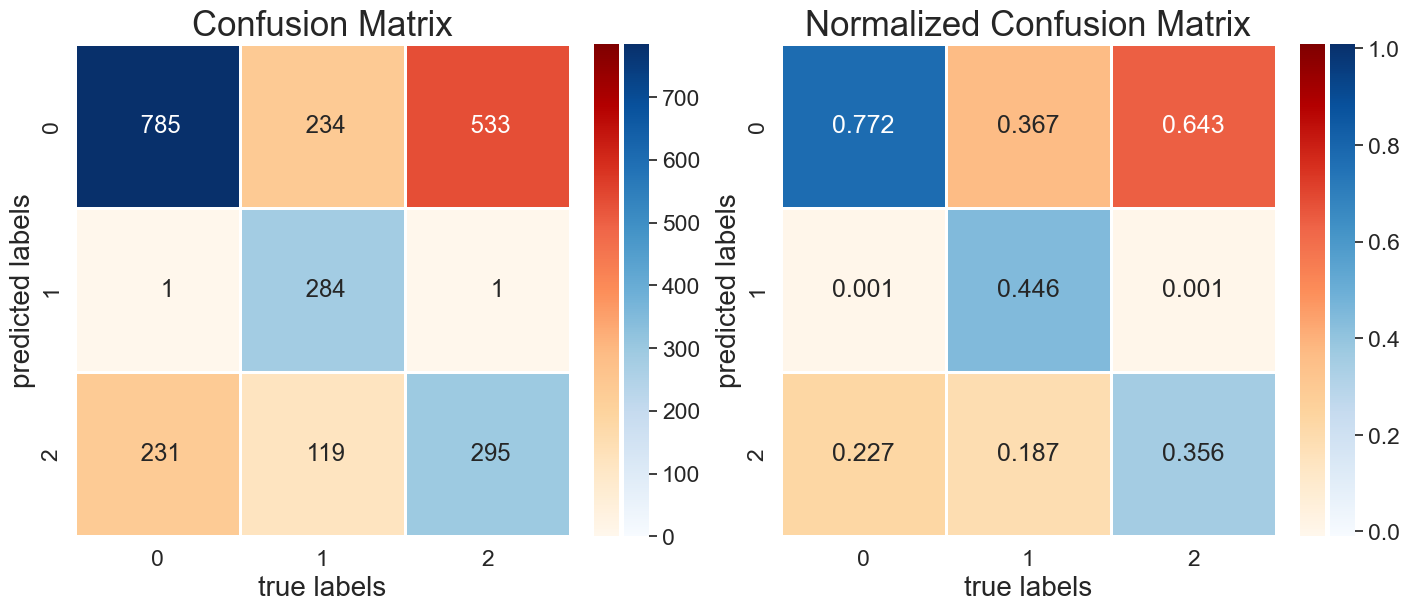

Balanced Accuracy:  52.45 %


In [ ]:
scores = get_performances(
    loader2eval=testloader,
    Model=model_curr,
    device=device,
    nb_classes=nb_classes,
    return_scores=True,
    verbose=verbose,
    plot_confusion=True,
    class_labels=classlabels,
)
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

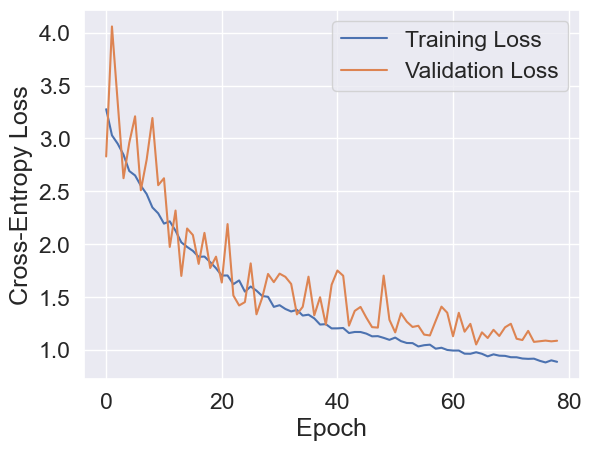

In [ ]:
training_loss_curve = []
validation_loss_curve = []
# Iterate through the dictionary, filtering out entries with None values
for key, (train_loss, val_loss) in loss_summary.items():
    if train_loss is not None and val_loss is not None:
        training_loss_curve.append(train_loss)
        validation_loss_curve.append(val_loss)

scores["training_loss_curve"] = training_loss_curve
scores["validation_loss_curve"] = validation_loss_curve

plt.plot(training_loss_curve, label="Training Loss")
plt.plot(validation_loss_curve, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.show()

## Save the model

In [ ]:
model_name = f"xeeg_test_mini.pt"

dir_models = os.path.join(dir_shallownetXAI, "newmodels") + sep
model_path = os.path.join(dir_models, model_name)

dirResults = os.path.join(dir_shallownetXAI, "new_results") + sep
results_path = os.path.join(dirResults, f"{model_name[:-3]}_results.pickle")

In [ ]:
results_path

'../../backend\\experiments_xeegnet\\shallownetXAI-main\\new_results\\xeeg_test_mini_results.pickle'

In [ ]:
print("model dir:", dir_models, os.path.isdir(dir_models))
print("model path:", model_path, os.path.abspath(model_path))
print("results dir:", dirResults, os.path.isdir(dirResults))
print("results path:", results_path, os.path.abspath(results_path), os.path.exists(results_path))

model dir: ../../backend\experiments_xeegnet\shallownetXAI-main\newmodels\ True
model path: ../../backend\experiments_xeegnet\shallownetXAI-main\newmodels\xeeg_test_mini.pt c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI-main\newmodels\xeeg_test_mini.pt
results dir: ../../backend\experiments_xeegnet\shallownetXAI-main\new_results\ True
results path: ../../backend\experiments_xeegnet\shallownetXAI-main\new_results\xeeg_test_mini_results.pickle c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI-main\new_results\xeeg_test_mini_results.pickle False


In [ ]:
save_model = True

if save_model:
    # Save the model
    model_curr.eval()
    model_curr.to(device="cpu")
    torch.save(model_curr.state_dict(), model_path)

    # Save the scores
    with open(results_path, "wb") as handle:
        pickle.dump(scores, handle, protocol=pickle.HIGHEST_PROTOCOL)